# Spatiotemporal Analysis of Mangrove Health

## 1. Setup and Data Loading

Import necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skyborn.calc import mann_kendall_multidim
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['xtick.labelsize'] = 18    # X轴刻度标签大小
plt.rcParams['ytick.labelsize'] = 18    # Y轴刻度标签大小
plt.rcParams['axes.labelsize'] = 20     # 坐标轴标签大小

# Load the dataset
file_path = 'final_environment_with_MHI.csv'
df = pd.read_csv(file_path)



## 2. Theil-Sen and Mann-Kendall Trend Analysis (using skyborn)

Reshape the data and calculate the Theil-Sen slope and Mann-Kendall p-value for the `kNDVI_mean_mangrove` time series for each `GridID` using the efficient `skyborn` library.

In [2]:
# Reshape the data from long to wide format
df_pivot = df.pivot_table(index='year', columns='GridID', values='MHI')
data_array = df_pivot.values

# Get the GridIDs in the correct order
grid_ids = df_pivot.columns

# Perform Mann-Kendall trend test on the 2D array (years, locations)
mk_result = mann_kendall_multidim(data_array, axis=0)
slopes = mk_result['trend']
p_values = mk_result['p']

# Combine the results into a DataFrame
trend_results = pd.DataFrame({
    'GridID': grid_ids,
    'slope': slopes,
    'p_value': p_values
})

print("Trend analysis complete.")
print(trend_results.head())

Trend analysis complete.
   GridID     slope   p_value
0      18 -0.638756  0.462433
1      24       NaN       NaN
2      31       NaN       NaN
3      32  0.497129  0.220671
4      33  2.084846  0.308180


## 3. Classify Trends and Create GeoDataFrame

Classify the trends into five categories and merge the results with geographic coordinates to create a GeoDataFrame.

In [3]:
def classify_trend(row):
    """Classifies the trend based on slope and p-value."""
    p_value = row['p_value']
    slope = row['slope']
    
    if pd.isna(p_value) or pd.isna(slope):
        return 'No Data'
    
    # Define thresholds
    p_significant = 0.05
    slope_stable_threshold = 0.1
    
    if slope > slope_stable_threshold:
        if p_value < p_significant:
            return 'Significant Recovery'
        else:
            return 'Slight Recovery'
    elif slope < -slope_stable_threshold:
        if p_value < p_significant:
            return 'Significant Degradation'
        else:
            return 'Slight Degradation'
    else:
        return 'Stable'

# Apply the classification
trend_results['category'] = trend_results.apply(classify_trend, axis=1)

# Get unique coordinates for each GridID
coords = df[['GridID', 'lon', 'lat']].drop_duplicates('GridID')

# Merge trend results with coordinates
merged_df = pd.merge(trend_results, coords, on='GridID')

# Create GeoDataFrame
geometry = [Point(xy) for xy in zip(merged_df['lon'], merged_df['lat'])]
gdf = gpd.GeoDataFrame(merged_df, geometry=geometry, crs='EPSG:4326')

print("Classification and GeoDataFrame creation complete.")
print(gdf.head())
print('\nValue counts for each category:')
print(gdf['category'].value_counts())

Classification and GeoDataFrame creation complete.
   GridID     slope   p_value            category         lon        lat  \
0      18 -0.638756  0.462433  Slight Degradation  112.356284  21.979372   
1      24       NaN       NaN             No Data  112.361210  21.732916   
2      31       NaN       NaN             No Data  112.363510  21.975401   
3      32  0.497129  0.220671     Slight Recovery  112.363584  21.983223   
4      33  2.084846  0.308180     Slight Recovery  112.363659  21.991045   

                     geometry  
0  POINT (112.35628 21.97937)  
1  POINT (112.36121 21.73292)  
2   POINT (112.36351 21.9754)  
3  POINT (112.36358 21.98322)  
4  POINT (112.36366 21.99104)  

Value counts for each category:
category
Slight Recovery            632
No Data                    457
Slight Degradation         134
Stable                      83
Significant Recovery        46
Significant Degradation      1
Name: count, dtype: int64


## 4. Analyze Landscape Pattern Dynamics

Analyze the temporal changes in `patch_density` and `area_mn`.

In [4]:
# Calculate the mean of landscape metrics for each year
landscape_dynamics = df.groupby('year')[['patch_density', 'area_mn']].mean().reset_index()

print("Landscape pattern dynamics analysis complete.")
print(landscape_dynamics)

Landscape pattern dynamics analysis complete.
   year  patch_density   area_mn
0  2000       3.820577  0.257102
1  2005       1.510474  0.142041
2  2010       2.894336  0.349489
3  2015       3.595481  0.669596
4  2020       3.805984  0.906070
5  2024       5.180542  0.889492


## 5. Visualization

### 5.1. Spatiotemporal Pattern Map

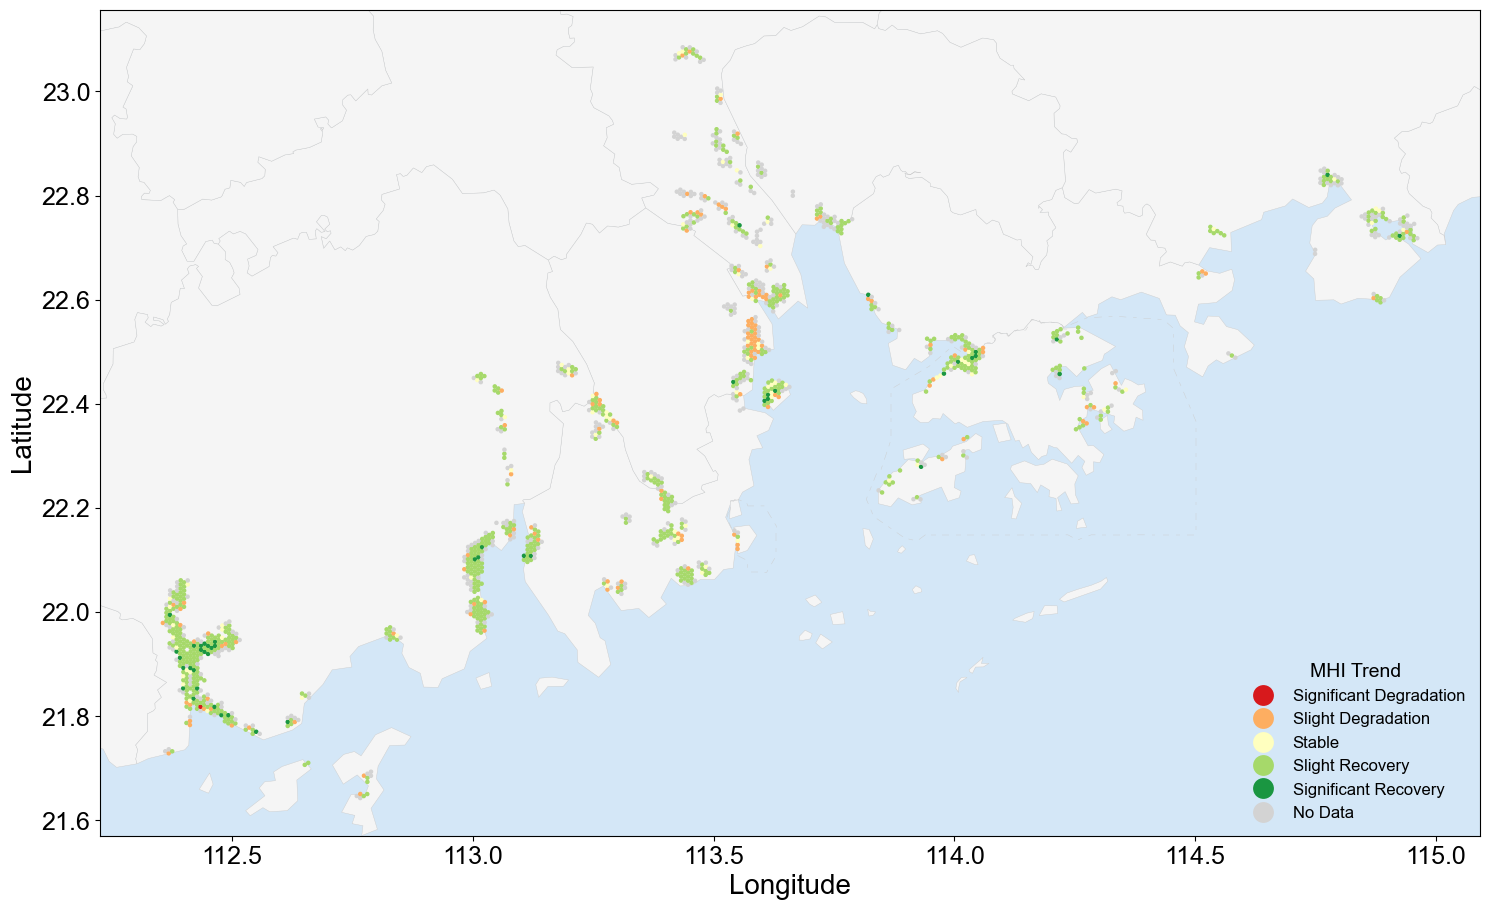

In [5]:
import matplotlib.colors as mcolors
import numpy as np
# Define the color map and order for the categories
category_order = [
    'Significant Degradation',
    'Slight Degradation',
    'Stable',
    'Slight Recovery',
    'Significant Recovery',
    'No Data'
]
colors = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641', '#D3D3D3'] # Red-Yellow-Green + Grey
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(np.arange(len(category_order) + 1) - 0.5, len(category_order))
# Convert category to a categorical type for plotting
gdf['category'] = pd.Categorical(gdf['category'], categories=category_order, ordered=True)

# --- Basemap Integration Start ---
# 1. Load Basemap
basemap_path = 'buffer/中国_市.geojson'
try:
    basemap_gdf = gpd.read_file(basemap_path)
    
    # 2. CRS Alignment
    if basemap_gdf.crs != gdf.crs:
        basemap_gdf = basemap_gdf.to_crs(gdf.crs)

    # 3. Calculate Extent with Padding
    minx, miny, maxx, maxy = gdf.total_bounds
    x_range = maxx - minx
    y_range = maxy - miny
    padding_x = x_range * 0.05
    padding_y = y_range * 0.05

    # 4. Clip Basemap
    basemap_gdf = basemap_gdf.cx[minx-padding_x:maxx+padding_x, miny-padding_y:maxy+padding_y]
    
except Exception as e:
    print(f"Error loading or processing basemap: {e}")
    basemap_gdf = None
# --- Basemap Integration End ---

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# 5. Ocean Background
ocean_color = '#d4e7f7'
ax.set_facecolor(ocean_color)

# 6. Plot Basemap (Land)
if basemap_gdf is not None:
    basemap_gdf.plot(
        ax=ax,
        facecolor='#f5f5f5',  # Light gray for land
        edgecolor='#cccccc',  # Gray border
        linewidth=0.3,
        zorder=1
    )

# 使用 legend_kwds 统一控制图例
legend_kwds = {
    'title': 'MHI Trend',
    'loc': 'lower right',
    'fontsize': 12,          # 图例标签字体大小
    'title_fontsize': 14,    # 图例标题字体大小
    'frameon': False,        # 去掉边框
    'markerscale': 1.5,      # 调大图例中的点，方便看清颜色
}

# Plot the data
gdf.plot(
    column='category', 
    cmap=cmap, 
    norm=norm, 
    ax=ax, 
    legend=True, 
    markersize=5,
    legend_kwds=legend_kwds,  # 将设置传递给图例
    zorder=2
)

# 注意：由于已经在 legend_kwds 中设置了 title 和 frameon，
# 下面的手动修改逻辑大部分可以简化。
# 如果 category_order 已经正确应用到 gdf['category']，图例标签会自动匹配。
# 进一步微调（如果需要手动修改文本）：
leg = ax.get_legend()
if leg:
    # 如果还需要对文本颜色或特定的字体进行精细控制：
    for text in leg.get_texts():
        text.set_fontweight('medium') # 示例：设置中等粗细
# Set axis labels
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)

# 7. Set Axis Limits
if basemap_gdf is not None:
    ax.set_xlim(minx-padding_x, maxx+padding_x)
    ax.set_ylim(miny-padding_y, maxy+padding_y)

# 确保图例不被遮挡或切断
# bbox_inches='tight' 在 savefig 时非常重要
plt.tight_layout()
plt.savefig('mhi_trend_map.png', dpi=300, bbox_inches='tight') 
plt.show()